In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import  classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [4]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [5]:
df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [6]:
df.nunique()

id                      593994
annual_income           119728
debt_to_income_ratio       526
credit_score               399
loan_amount             111570
interest_rate             1454
gender                       3
marital_status               4
education_level              5
employment_status            5
loan_purpose                 8
grade_subgrade              30
loan_paid_back               2
dtype: int64

In [7]:
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
num_cols = df.drop(columns = ['loan_paid_back']).select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols

['gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

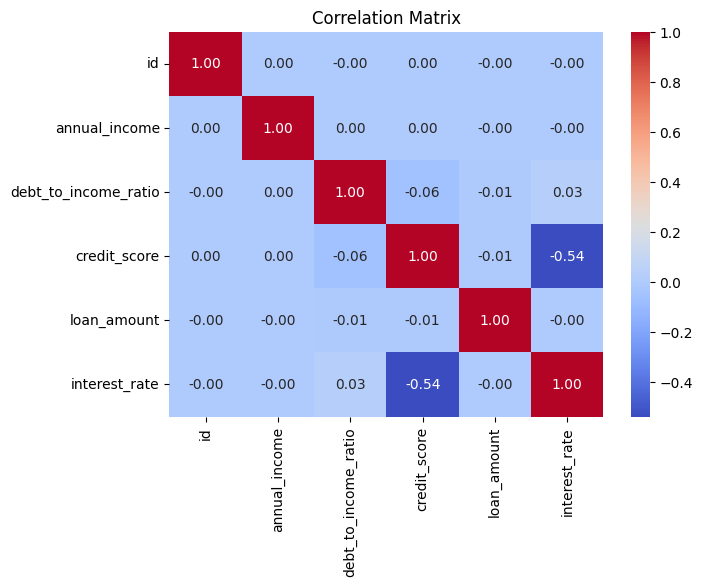

In [8]:
corrmatrix = df[num_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corrmatrix, annot=True, cmap='coolwarm',fmt= '.2f')
plt.title('Correlation Matrix')
plt.show()

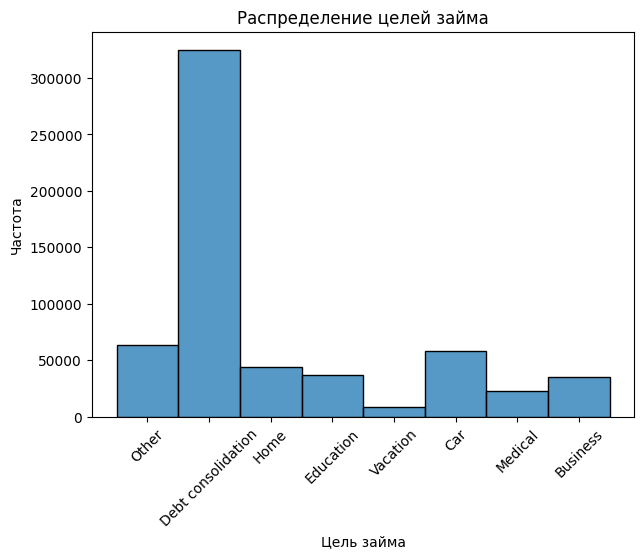

In [9]:
plt.figure(figsize=(7, 5))
sns.histplot(x='loan_purpose', data=df) 
plt.title('Распределение целей займа')
plt.xlabel('Цель займа')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.show()

In [10]:
#profile = ProfileReport(df, title = "Predicting loan Report")
#profile.to_file("loan_report.html")

In [11]:
target = 'loan_paid_back'
X = df.drop(columns=[target])
y = df[target]
X_test_final = df_test

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
cat_cols.remove('grade_subgrade')
cat_ord_cols = ['grade_subgrade']

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('cat_ord', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_ord_cols)
    ])  

In [31]:
x_train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade'],
      dtype='object')

In [14]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(X_test_final))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(x_train, y_train)):
    X_train_f, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_train_f, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators = 2000,
            learning_rate = 0.05,
            max_depth = 6,
            random_state = 42,
            eval_metric = 'auc'
        ))
    ])
    model_pipeline.fit(X_train_f, y_train_f)

    probs = model_pipeline.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, probs)
    fold_scores.append(auc_val)

    test_preds += model_pipeline.predict_proba(X_test_final)[:, 1] / kf.n_splits
    print(f'Fold {fold+1} | AUC: {auc_val:.4f}')

print(f'Average ROC AUC: {np.mean(fold_scores):.4f}')

Fold 1 | AUC: 0.9171
Fold 2 | AUC: 0.9209
Fold 3 | AUC: 0.9191
Fold 4 | AUC: 0.9201
Fold 5 | AUC: 0.9198
Average ROC AUC: 0.9194


In [24]:
y_pred = model_pipeline.predict(x_test)
y_proba = model_pipeline.predict_proba(x_test)[:, 1]

print("\n Тестовые метрики:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



 Тестовые метрики:
Accuracy: 0.9034
ROC AUC Score: 0.9201

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.61      0.72     23997
         1.0       0.91      0.98      0.94     94802

    accuracy                           0.90    118799
   macro avg       0.89      0.79      0.83    118799
weighted avg       0.90      0.90      0.90    118799



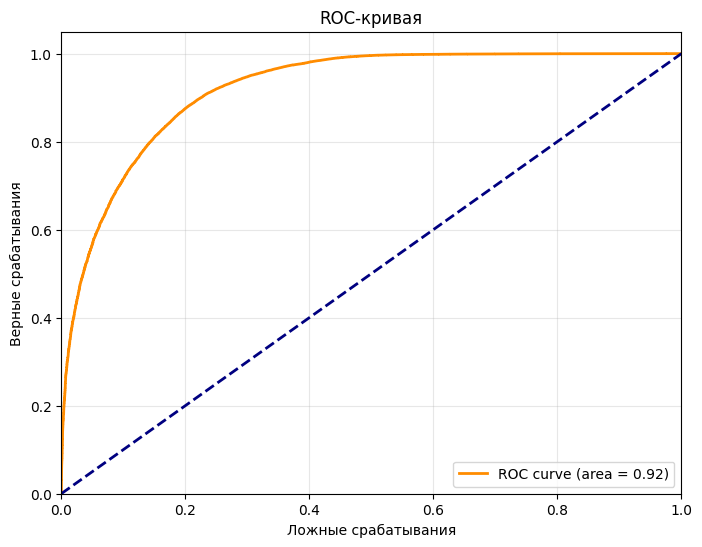

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Ложные срабатывания')
plt.ylabel('Верные срабатывания')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


/var/folders/l1/t3rml9dj3c5_2blf8jgn4xg00000gn/T/ipykernel_49573/358347276.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


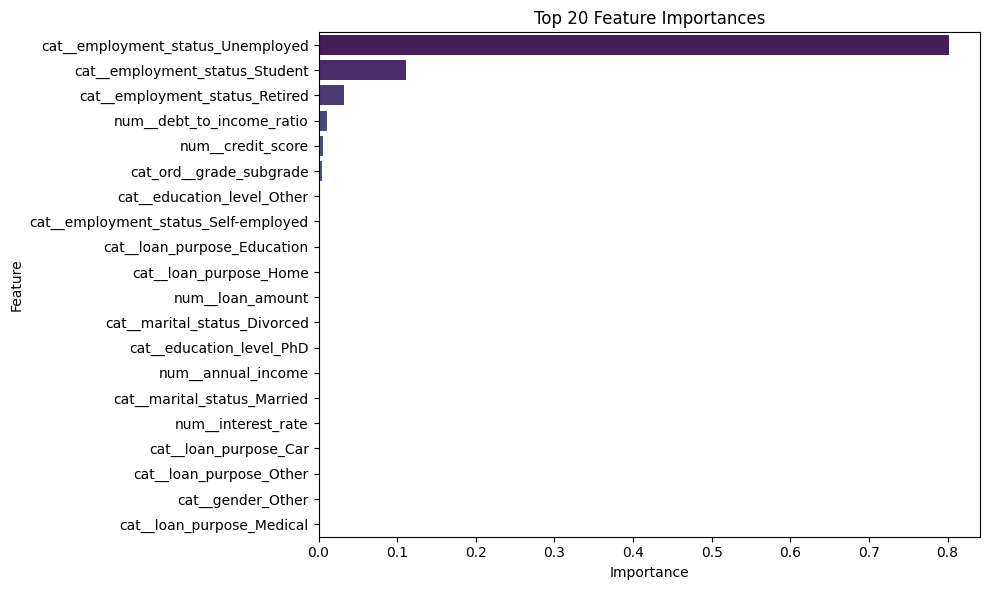

In [21]:
importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()      